In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed panel containing momentum signals
df = pd.read_parquet('../data/processed/backtest_panel_with_signals.parquet')

# Ensure proper chronological sorting per stock
df = df.sort_values(['permno', 'rebalance_date']).reset_index(drop=True)

In [3]:
# %%
# Generate 1-month forward returns if they aren't already part of the dataset
if 'fwd_return' not in df.columns:
    df['fwd_return'] = df.groupby('permno')['true_total_return'].shift(-1)

# %%
# Assign cross-sectional quintiles based on the winsorized momentum signal
df['quintile'] = df.groupby('rebalance_date')['momentum_12_1'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)

# %%
# Compute equal-weighted forward returns for each quintile per rebalance period
port_returns = df.groupby(['rebalance_date', 'quintile'])['fwd_return'].mean().reset_index()
port_pivot = port_returns.pivot(index='rebalance_date', columns='quintile', values='fwd_return')
port_pivot.columns = ['Q1_Losers', 'Q2', 'Q3', 'Q4', 'Q5_Winners']

# Calculate Long/Short spread (Q5 Winners minus Q1 Losers)
port_pivot['Long_Short'] = port_pivot['Q5_Winners'] - port_pivot['Q1_Losers']

# Compute cumulative returns (filling missing periods with 0 return if necessary)
cum_returns = (1 + port_pivot.fillna(0)).cumprod()

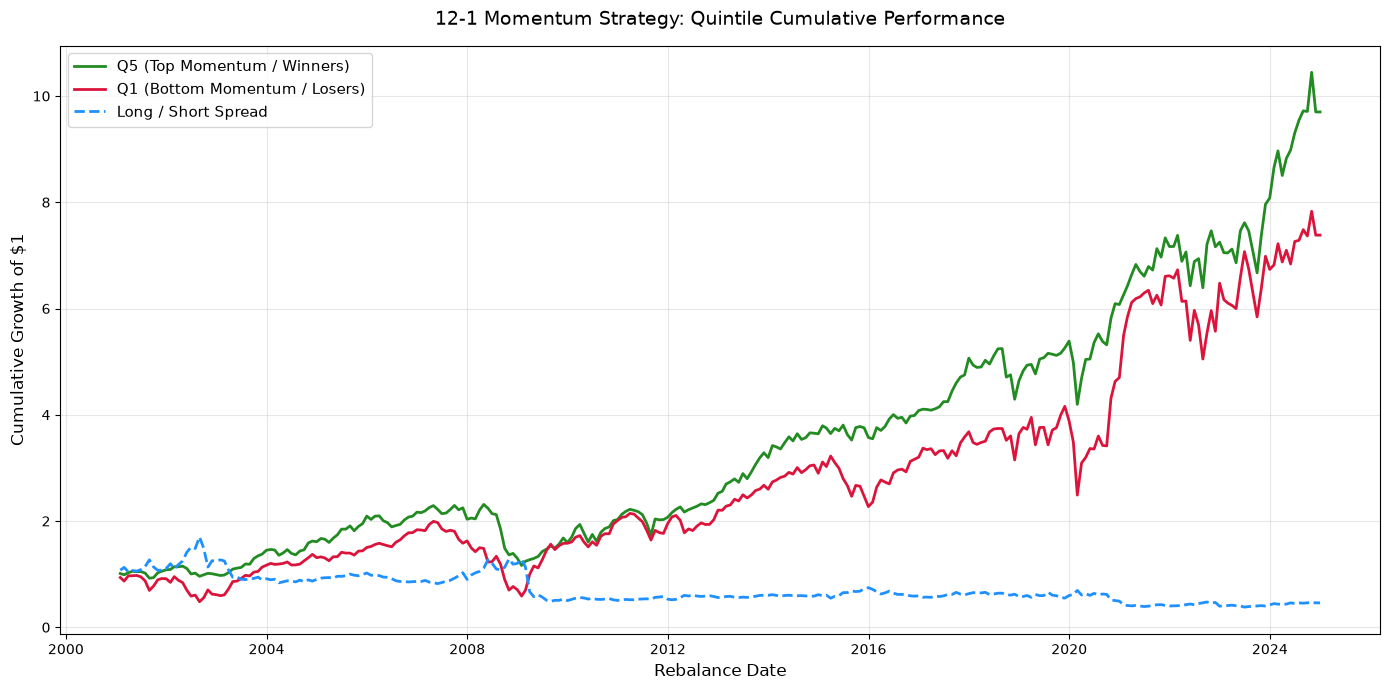

In [5]:
# %%
# Visualize Cumulative Portfolio Performance
plt.figure(figsize=(14, 7))
plt.plot(cum_returns.index, cum_returns['Q5_Winners'], label='Q5 (Top Momentum / Winners)', color='forestgreen', linewidth=2)
plt.plot(cum_returns.index, cum_returns['Q1_Losers'], label='Q1 (Bottom Momentum / Losers)', color='crimson', linewidth=2)
plt.plot(cum_returns.index, cum_returns['Long_Short'], label='Long / Short Spread', color='dodgerblue', linestyle='--', linewidth=2)

plt.title('12-1 Momentum Strategy: Quintile Cumulative Performance', fontsize=14, pad=15)
plt.xlabel('Rebalance Date', fontsize=12)
plt.ylabel('Cumulative Growth of $1', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()